# EnsemblePredictor Tutorial

This notebook demonstrates how to load and use the `EnsemblePredictor` class
for making PROTAC/degrader activity predictions with uncertainty quantification.

## Overview

The `EnsemblePredictor` combines predictions from multiple models (XGBoost and
MLP) trained across different cross-validation folds and feature sets. It
provides:

- **Weighted ensemble predictions** from all loaded models
- **Multi-task support** — models are grouped by their training task (e.g., Dmax, DC50, Binary)
- **Uncertainty estimates** (standard deviation, confidence intervals)
- **Two types of 95% CI**: percentile-based (non-parametric) and SEM-based (parametric)
- **Individual model predictions** for further analysis
- **Automatic feature encoding** via the saved datamodules

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from tackai.ensemble_predictor import EnsemblePredictor, SampleInput

# Disable warnings for cleaner output
warnings.filterwarnings("ignore")

/home/x_steri/storage/TACK/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Loading the Ensemble

### 1.1 Loading from a directory (uniform weights)

The simplest way to create an `EnsemblePredictor` is to point it at a
directory that contains model checkpoints (`.ckpt` for MLP, `.json` for
XGBoost) and their associated datamodule files (`_hparams.yaml` +
`_state.pt`).  In this scenario, all models receive equal weight.

> **Note:** Every model must have a corresponding datamodule. If any model
> is missing its datamodule, loading will fail with an error.

After downloading and unzipping files from [this download link](https://zenodo.org/records/15691822/files/ensembles.zip?download=1), we will assume a `ensembles/` directory with subfolders for the different ensemble types (e.g., `bin_caruana_ensemble/`).

In [3]:
PROJ_DIR = Path("..")  # TACK project root (one level up from notebooks/)
EMBEDDINGS_PATH = PROJ_DIR / "embeddings.npz"   # shared protein + cell-line embeddings

ENSEMBLE_CHECKPOINT_DIR = PROJ_DIR / "ensembles/bin_caruana_ensemble"
ENSEMBLE_WEIGHTS_PATH = ENSEMBLE_CHECKPOINT_DIR / "ensemble_weights_bin_caruana_all_models.json"

predictor = EnsemblePredictor.from_directory(
    model_dir=ENSEMBLE_CHECKPOINT_DIR,
    weights_file=ENSEMBLE_WEIGHTS_PATH,   # Caruana selection weights; omit for uniform weights
    device="cpu",
    hparam_overrides={
        "poi_embeddings_file": str(EMBEDDINGS_PATH),
        "ligase_embeddings_file": str(EMBEDDINGS_PATH),
    },
    lazy_loading=True, # Set to False to load all models into memory at once (may require more RAM and crash the notebook kernel)
)
print(predictor)

Loaded weights from ensemble_weights_bin_caruana_all_models.json (task=bin, method=caruana_all_models, 18 models)
Registering 18 model(s) from ../ensembles/bin_caruana_ensemble
  Registered (1/18): model=mlp_bin_protac-data=all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=16 (lightning)
  Registered (2/18): model=mlp_bin_protac-data=all_desc_poi_onehot_lig_onehot_cell_onehot_assay_time_labels_Activity-group=scaffold-fold=13 (lightning)
  Registered (3/18): model=mlp_bin_protac-data=all_desc_poi_onehot_lig_onehot_cell_onehot_assay_time_labels_Activity-group=scaffold-fold=21 (lightning)
  Registered (4/18): model=xgboost_bin_protac-data=all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=2 (xgboost)
  Registered (5/18): model=xgboost_bin_protac-data=all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=3 (xgboost)
  Registered (6/18): model=x

### 1.3 Inspecting the loaded models

You can inspect which models were loaded, their types, and weights.

In [4]:
info = predictor.get_model_info()

print(f"Task(s):         {info['available_tasks']}")
print(f"Models types:    {list(set(list(info['model_types'].values())))}")
print(f"Total models:    {info['n_models']}")
print()

# Count by type
type_counts = Counter(info["model_types"].values())
for model_type, count in type_counts.items():
    print(f"  {model_type}: {count}")

Task(s):         ['bin']
Models types:    ['xgboost', 'lightning']
Total models:    18

  lightning: 3
  xgboost: 15


In [5]:
info = predictor.get_model_info()
for name in info['model_names']:
    print(f"{name}: {info['model_types'][name]} (task={info['model_tasks'][name]})")

model=mlp_bin_protac-data=all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=16: lightning (task=bin)
model=mlp_bin_protac-data=all_desc_poi_onehot_lig_onehot_cell_onehot_assay_time_labels_Activity-group=scaffold-fold=13: lightning (task=bin)
model=mlp_bin_protac-data=all_desc_poi_onehot_lig_onehot_cell_onehot_assay_time_labels_Activity-group=scaffold-fold=21: lightning (task=bin)
model=xgboost_bin_protac-data=all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=2: xgboost (task=bin)
model=xgboost_bin_protac-data=all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=3: xgboost (task=bin)
model=xgboost_bin_protac-data=all_desc_poi_onehot_lig_onehot_cell_text_assay_time_labels_Activity-group=scaffold-fold=12: xgboost (task=bin)
model=xgboost_bin_protac-data=all_desc_poi_onehot_lig_onehot_cell_text_assay_time_labels_Activity-group=scaffold-fold=1

In [6]:
# Show individual model weights (sorted by weight, descending)
weights_df = pd.DataFrame([
    {"model": name, "type": info["model_types"][name], "weight": w}
    for name, w in info["weights"].items()
]).sort_values("weight", ascending=False).reset_index(drop=True)

weights_df

,model,type,weight
0,model=xgboost_bin_protac-data=all_desc_poi_one...,xgboost,0.243810
1,model=xgboost_bin_protac-data=all_desc_poi_one...,xgboost,0.234560
2,model=mlp_bin_protac-data=all_desc_poi_onehot_...,lightning,0.148115
3,model=xgboost_bin_protac-data=all_desc_poi_one...,xgboost,0.102857
4,model=mlp_bin_protac-data=all_desc_poi_onehot_...,lightning,0.080000
5,model=xgboost_bin_protac-data=all_desc_poi_one...,xgboost,0.066667
6,model=xgboost_bin_protac-data=all_desc_poi_one...,xgboost,0.043810
7,model=xgboost_bin_protac-data=all_desc_poi_emb...,xgboost,0.016190
8,model=mlp_bin_protac-data=all_desc_poi_emb_lig...,lightning,0.014286
9,model=xgboost_bin_protac-data=all_desc_poi_one...,xgboost,0.013751


In [7]:
info = predictor.get_model_info()
print(f"Available tasks : {info['available_tasks']}")
print(f"Total models    : {info['n_models']}")
print()
print(f"{'Model':<60}  {'Type':<10}  {'Task':<8}  Weight")
print("-" * 88)
for name in info['model_names']:
    w = info['weights'].get(name, 0.0)
    t = info['model_types'][name]
    task = info['model_tasks'][name]
    print(f"  {name[:58]:<58}  {t:<10}  {task:<8}  {w:.4f}")

Available tasks : ['bin']
Total models    : 18

Model                                                         Type        Task      Weight
----------------------------------------------------------------------------------------
  model=mlp_bin_protac-data=all_desc_poi_emb_lig_emb_cell_te  lightning   bin       0.0143
  model=mlp_bin_protac-data=all_desc_poi_onehot_lig_onehot_c  lightning   bin       0.1481
  model=mlp_bin_protac-data=all_desc_poi_onehot_lig_onehot_c  lightning   bin       0.0800
  model=xgboost_bin_protac-data=all_desc_poi_emb_lig_emb_cel  xgboost     bin       0.0162
  model=xgboost_bin_protac-data=all_desc_poi_emb_lig_emb_cel  xgboost     bin       0.0019
  model=xgboost_bin_protac-data=all_desc_poi_onehot_lig_oneh  xgboost     bin       0.0067
  model=xgboost_bin_protac-data=all_desc_poi_onehot_lig_oneh  xgboost     bin       0.0010
  model=xgboost_bin_protac-data=all_desc_poi_onehot_lig_oneh  xgboost     bin       0.2438
  model=xgboost_bin_protac-data=all_desc_poi

## 2. Making Predictions

### 2.1 Single prediction with `SampleInput`

The `SampleInput` dataclass wraps all the possible input fields.  Only
`smiles` is strictly required — missing fields are filled with sensible
defaults.

In [8]:
# All models in this ensemble require POI_Sequence (not just POI_Name)
AR_SEQ = "MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAASAAPPGASLLLLQQQQQQQQQQQQQQQQQQQQQQQETSPRQQQQQQGEDGSPQAHRRGPTGYLVLDEEQQPSQPQSALECHPERGCVPEPGAAVAASKGLPQQLPAPPDEDDSAAPSTLSLLGPTFPGLSSCSADLKDILSEASTMQLLQQQQQEAVSEGSSSGRAREASGAPTSSKDNYLGGTSTISDNAKELCKAVSVSMGLGVEALEHLSPGEQLRGDCMYAPLLGVPPAVRPTPCAPLAECKGSLLDDSAGKSTEDTAEYSPFKGGYTKGLEGESLGCSGSAAAGSSGTLELPSTLSLYKSGALDEAAAYQSRDYYNFPLALAGPPPPPPPPHPHARIKLENPLDYGSAWAAAAAQCRYGDLASLHGAGAAGPGSGSPSAAASSSWHTLFTAEEGQLYGPCGGGGGGGGGGGGGGGGGGGGGGGEAGAVAPYGYTRPPQGLAGQESDFTAPDVWYPGGMVSRVPYPSPTCVKSEMGPWMDSYSGPYGDMRLETARDHVLPIDYYFPPQKTCLICGDEASGCHYGALTCGSCKVFFKRAAEGKQKYLCASRNDCTIDKFRRKNCPSCRLRKCYEAGMTLGARKLKKLGNLKLQEEGEASSTTSPTEETTQKLTVSHIEGYECQPIFLNVLEAIEPGVVCAGHDNNQPDSFAALLSSLNELGERQLVHVVKWAKALPGFRNLHVDDQMAVIQYSWMGLMVFAMGWRSFTNVNSRMLYFAPDLVFNEYRMHKSRMYSQCVRMRHLSQEFGWLQITPQEFLCMKALLLFSIIPVDGLKNQKFFDELRMNYIKELDRIIACKRKNPTSCSRRFYQLTKLLDSVQPIARELHQFTFDLLIKSHMVSVDFPEMMAEIISVQVPKILSGKVKPIYFHTQ"
E3_SEQ = "MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNIINFDTSLPTSHTYLGADMEEFHGRTLHDDDSCQVIPVLPQVMMILIPGQTLPLQLFHPQEVSMVRNLIQKDRTFAVLAYSNVQEREAQFGTTAEIYAYREEQDFGIEIVKVKAIGRQRFKVLELRTQSDGIQQAKVQILPECVLPSTMSAVQLESLNKCQIFPSKPVSREDQCSYKWWQKYQKRKFHCANLTSWPRWLYSLYDAETLMDRIKKQLREWDENLKDDSLPSNPIDFSYRVAACLPIDDVLRIQLLKIGSAIQRLRCELDIMNKCTSLCCKQCQETEITTKNEIFSLSLCGPMAAYVNPHGYVHETLTVYKACNLNLIGRPSTEHSWFPGYAWTVAQCKICASHIGWKFTATKKDMSPQKFWGLTRSALLPTIPDTEDEISPDKVILCL"

sample = SampleInput(
    smiles="CC1(C)[C@H](NC(=O)c2ccc(N3CCN(CCCOc4ccc(C(=O)NC5CCC(=O)NC5=O)nc4)CC3)nc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1",
    poi_name="AR",
    poi_sequence=AR_SEQ,
    ligase_name="CRBN",
    ligase_sequence=E3_SEQ,
    cell_line="Unknown",
    assay_type="Unknown",
    treatment_time=24.0,
)

# predict() returns a dict: task_name → EnsemblePrediction
# EXAMPLE: Use task_results['dmax'] for Dmax predictions
task_results = predictor.predict(sample, tasks=['bin'])

# For a single-task ensemble, extract the first (only) result
task_name = list(task_results.keys())[0]
result = task_results[task_name]
print(f"Task: {task_name}")
print(result.summary())
print('')
print("Full result as dict:")
print(result.to_dict())

Task: bin
Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.1388 ± 0.1081
95% CI (percentile): [0.0125, 0.3826]
95% CI (SEM):        [0.0874, 0.1902]

Full result as dict:
{'weighted_mean': [0.1388114057963049], 'uncertainty_std': [0.10809483394549897], 'ci_percentile_lower_95': [0.01251491557341069], 'ci_percentile_upper_95': [0.38256176114082324], 'ci_sem_lower_95': [0.08742638349253129], 'ci_sem_upper_95': [0.19019642810007853], 'prediction_variance': [0.011684493125704996], 'prediction_range': [0.44664257299154997], 'prediction_iqr': [0.12541678547859192], 'predictive_entropy': [0.40279996104226146], 'model_names': ['model=mlp_bin_protac-data=all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=16', 'model=mlp_bin_protac-data=all_desc_poi_onehot_lig_onehot_cell_onehot_assay_time_labels_Activity-group=scaffold-fold=13', 'model=mlp_bin_protac-data=all_desc_poi_onehot_lig_onehot_cell_onehot_assay_time_labels_Activity-gr

In [9]:
smiles_list = [
    'Cn1c(=O)n(C2CCC(=O)NC2=O)c2cccc(C#CCCN3CCC4(CC3)CC(n3cc(NC(=O)c5cnn6ccc(N7C[C@H]8C[C@@H]7CO8)nc56)c(C(F)F)n3)C4)c21',
    'Cc1ncsc1C1=CCC([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)C(c2cc(N3CCC(CN4CCC(n5nc(NC(C)C)c6nnc(-c7cccc(F)c7O)cc65)CC4)CC3)no2)C(C)C)C=C1',
    'COc1ccccc1C(=O)NCc1ccc(-c2nn3c(c2C(N)=O)Nc2ccc(N4CCN(CC5CCN(c6ccc(N7CCC(=O)NC7=O)cc6)CC5)CC4)cc2CC3)c(OC)c1',
    'C[C@H]1CC2(CCN(c3ccc(C(=O)N4CCC(N5CCC(N6CCN(c7ccc(N8CCC(=O)NC8=O)cc7)CC6)CC5)CC4)cc3)CC2)CN1c1ccc(C#N)c(Cl)c1',
    'COc1cc(N2CCC(N3CCN(C(=O)C4CCN(c5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)CC3)CC2)c(C)cc1Nc1ncc(Cl)c(Nc2cccc3c2N(S(C)(=O)=O)CC3)n1',
    'CC(C1CN(c2cc3c(cc2F)C(=O)N(C2CCC(=O)NC2=O)C3=O)C1)N1CCC(c2cn3cc(NC(=O)c4cccc(C5CC5(F)F)n4)c(C(C)(C)O)c(F)c3n2)CC1',
    'O=C1CCC(N2C(=O)c3cccc(NC(=O)C[C@@H]4CCN(CCc5cc(O)c(N6CC(=O)NS6(=O)=O)c(F)c5)C4)c3C2=O)C(=O)N1',
    'Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCCCCCCCN(C)CCOC23CC4(C)CC(C)(CC(Cn5ncc(-c6ccc(N7CCCc8c7nnc(Nc7nc9ccccc9s7)c8C)nc6C(=O)O)c5C)(C4)C2)C3)C(C)(C)C)cc1',
    'Cc1cccc(NC(=O)c2ccc(-c3nn4c(c3C(N)=O)Nc3ccc(N5CCN(CC6CCN(c7ccc(N8CCC(=O)N(CC(=O)OC(C)(C)C)C8=O)cc7)CC6)CC5)cc3CC4)c(F)c2C)n1',
    'Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCCC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc5c(c4)OC[C@@H]4CN(CC6=C(c7ccc(Cl)cc7)CCC(C)(C)C6)CCN54)cc3S(=O)(=O)C(F)(F)F)CC2)C(C)(C)C)cc1',
    'COc1cc2nn(C3CC4(CCC(C(=O)N5CCN(c6ccc7c(c6)C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CC4)C3)cc2cc1NC(=O)c1cccc(C(F)(F)F)n1',
    'Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2C1CCN(CCCCCCOCCOCC(=O)Nc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1',
    'Cn1c(=O)n(C2CCC(=O)NC2=O)c2cccc(C#CCN3CC[C@@H](CN4CCC5(CC4)CC(n4cc(NC(=O)c6cnn7ccc(N8C[C@H]9C[C@@H]8CO9)nc67)c(C(F)F)n4)C5)C3)c21',
    'CC1(C)CC(=C(c2ccc(N3CCC(CN4CCN(c5ccc(C(=O)N[C@H]6CCC(=O)NC6=O)c(F)c5)CC4)CC3)nc2)c2ccc3[nH]nc(F)c3c2)CC(C)(C)O1',
    'O=C1CCC(n2ncc(N3CCN(CC4CCN(c5ccc([C@@H]6c7ccc(O)cc7CC[C@@H]6c6ccccc6)cc5)CC4)CC3)cc2=O)C(=O)N1',
    'Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1CC[C@@H](N2CCN(C3CN(c4ccc5c(c4)C(=O)N([C@@H]4CCC(=O)NC4=O)C5=O)C3)CC2)CC1',
    'CCn1c(C)c(S(C)(=O)=O)c(CCc2cc(F)cc(NS(=O)(=O)c3ccc(NC(CCN4CCN(C(=O)CCCOCC(=O)N[C@H](C(=O)N5C[C@H](O)C[C@H]5C(=O)N[C@@H](C)c5ccc(-c6scnc6C)cc5)C(C)(C)C)CC4)CSc4ccccc4)c([N+](=O)[O-])c3)c2)c1-c1ccc(F)cc1',
    'CCCNc1nn(C2CCN(CC3CCN(CC(=O)N[C@H](C(=O)N4C[C@H](O)C[C@H]4C(=O)N[C@@H](C)c4ccc(-c5scnc5C)cc4)C(C)(C)C)CC3)CC2)c2cc(-c3ccccc3O)nnc12',
    'CNc1nn(C2CCN(CC3CCN(c4cc(C(C(=O)N5C[C@H](O)C[C@H]5C(=O)N[C@@H](C)c5ccc(-c6scnc6C)cc5)C(C)C)on4)CC3)CC2)c2cc(-c3ccccc3O)nnc12',
    'C#Cc1cccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)nc(OCC5(CN6CCN(CC7CCN(c8ccc9c(c8)C(=O)N(C8CCC(=O)NC8=O)C9=O)CC7)CC6)CC5)nc4c3F)c12',
    'CS(=O)(=O)N1CCc2cccc(Nc3nc(Nc4ccc(N5CCC(N6CCN(CC7CN(c8ccc9c(c8)C(=O)N(C8CCC(=O)NC8=O)C9=O)C7)CC6)CC5)c(F)c4)nc4[nH]ccc34)c21',
    'CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN3c4ccc(C(=O)NS(=O)(=O)c5ccc(N[C@H](CCN6CCN(C(=O)CCCCCC(=O)N[C@H](C(=O)N7C[C@H](O)C[C@H]7C(=O)NCc7ccc8c(c7)OCc7ncsc7-8)C(C)(C)C)CC6)CSc6ccccc6)c(S(=O)(=O)C(F)(F)F)c5)cc4OC[C@@H]3C2)C1',
    'CC1(C)CC(=C(c2ccc(N3CCN(CC4CN(c5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)C4)CC3)cc2)c2ccc3[nH]nc(F)c3c2)CC(C)(C)O1',
    'CC1(C)CC(=C(c2ccc(N3CCN(C(=O)C4CCN(c5ccc6c(c5)CN(C5CCC(=O)NC5=O)C6=O)CC4)CC3)nc2)c2ccc3[nH]nc(F)c3c2)CC(C)(C)O1',
    'Cc1c(Nc2nc3ccccc3s2)nnc2c1CCCN2c1ccc(-c2cnn(CC34CC5(C)CC(C)(C3)CC(OCCN(C)CCCCCCCCCCOc3ccc6c(c3)C(=O)N(C3CCC(=O)NC3=O)C6=O)(C5)C4)c2C)c(C(=O)O)n1',
    'Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCNC(=O)c2nc(N3CCCc4c3nnc(Nc3nc5ccccc5s3)c4C)ccc2-c2cnn(CC34CC5(C)CC(C)(C3)CC(OCCN3CCCC3)(C5)C4)c2C)C(C)(C)C)cc1',
    'CN1CCN([C@@H]2CCCN(c3c(F)cc(C(N)=O)c4[nH]c(-c5ccc(C6CCN(CC7CCN(c8ccc(C(=O)N[C@H]9CCC(=O)NC9=O)nc8)CC7)CC6)cc5)cc34)C2)C1=O',
    'CCOc1cc(N2CCC(N3CCN(CCc4cc(F)c([C@H]5CCC(=O)NC5=O)c(F)c4)CC3)CC2)c(CC)cc1Nc1ncc(Br)c(Nc2ccc(CC)c3c2N(S(C)(=O)=O)CC3)n1',
    'Cc1cc(-c2ncnc3[nH]c(-c4ccc(C5CCN(CC6CCN(c7ccc(N8CCC(=O)NC8=O)cc7F)CC6)CC5)cc4)cc23)ccc1CNC(=O)c1nc(C(C)(C)C)no1',
    'Cc1cc(N2CCC(CN3CCN(c4ccc(-c5cc6c(-c7ccc([C@@H](C)NC(=O)c8noc(C(C)(C)C)n8)c(C)c7F)ncnc6[nH]5)nc4)CC3)CC2)ccc1N1CCC(=O)NC1=O',
]

samples = [
    SampleInput(
        smiles=smiles,
        poi_name="AR",
        poi_sequence=AR_SEQ,
        ligase_name="CRBN",
        ligase_sequence=E3_SEQ,
        cell_line="Unknown",
        treatment_time=24.0,
        assay_type='Unknown',
    )
    for smiles in smiles_list
]

# predict() handles both single samples and lists
batch_results = predictor.predict(samples, tasks=['bin'], verbose=True)

for i, res in enumerate(batch_results):
    print(f"Sample {i+1}:")
    print(f"  Ensemble bin: {res['bin'].summary()}")
    print('')
    if i >= 5:  # only print first 5 samples for brevity
        break

batch_results = predictor.predict(samples, verbose=True)

for i, res in enumerate(batch_results):
    print(f"Sample {i+1}:")
    print(f"  Ensemble bin: {res['bin'].summary()}")
    print('')
    if i >= 5:
        break

Predicting: 100%|██████████| 18/18 [01:30<00:00,  5.04s/it]


Sample 1:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.6634 ± 0.1119
95% CI (percentile): [0.4335, 0.8011]
95% CI (SEM):        [0.6101, 0.7166]

Sample 2:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.7135 ± 0.1537
95% CI (percentile): [0.3922, 0.8925]
95% CI (SEM):        [0.6404, 0.7865]

Sample 3:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.5012 ± 0.1456
95% CI (percentile): [0.2285, 0.7724]
95% CI (SEM):        [0.4320, 0.5705]

Sample 4:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.4538 ± 0.1278
95% CI (percentile): [0.3021, 0.7210]
95% CI (SEM):        [0.3930, 0.5146]

Sample 5:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.5942 ± 0.1370
95% CI (percentile): [0.2350, 0.7448]
95% CI (SEM):        [0.5291, 0.6593]

Sample 6:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models

Predicting: 100%|██████████| 18/18 [01:53<00:00,  6.33s/it]

Sample 1:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.6634 ± 0.1119
95% CI (percentile): [0.4335, 0.8011]
95% CI (SEM):        [0.6101, 0.7166]

Sample 2:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.7135 ± 0.1537
95% CI (percentile): [0.3922, 0.8925]
95% CI (SEM):        [0.6404, 0.7865]

Sample 3:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.5012 ± 0.1456
95% CI (percentile): [0.2285, 0.7724]
95% CI (SEM):        [0.4320, 0.5705]

Sample 4:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.4538 ± 0.1278
95% CI (percentile): [0.3021, 0.7210]
95% CI (SEM):        [0.3930, 0.5146]

Sample 5:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.5942 ± 0.1370
95% CI (percentile): [0.2350, 0.7448]
95% CI (SEM):        [0.5291, 0.6593]

Sample 6:
  Ensemble bin: Task: BIN
Label: Binary Activity
Number of models

The `predict()` method also accepts a plain dict. Keys must match the column names expected by the datamodule (the same names used in the training dataset), **not** the `SampleInput` field names.

In [10]:
sample_dict = {
    'SMILES': "CC1(C)[C@H](NC(=O)c2ccc(N3CCN(CCCOc4ccc(C(=O)NC5CCC(=O)NC5=O)nc4)CC3)nc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1",
    'POI_Name': "AR",
    'POI_Sequence': AR_SEQ,
    'Ligase_Name': "CRBN",
    'Ligase_Sequence': E3_SEQ,
    'Cell_Line_ID': "Unknown",
    'Assay_Time': 24.0,
    'Assay': 'Unknown',
}

task_results = predictor.predict(sample_dict)

task_name = list(task_results.keys())[0]
result = task_results[task_name]
print(f"Task: {task_name}")
print(result.summary())

Task: bin
Task: BIN
Label: Binary Activity
Number of models: 18
Prediction: 0.1388 ± 0.1081
95% CI (percentile): [0.0125, 0.3826]
95% CI (SEM):        [0.0874, 0.1902]


### 2.2 Accessing prediction details

The `EnsemblePrediction` object extracted from the task dict contains rich information.

Two kinds of 95% confidence interval are available:
- **Percentile CI**: non-parametric, shows "most models predict within this range"
- **SEM CI**: parametric, shows "the true average is likely in this range" (shrinks with more models)

In [11]:
print(f"Weighted mean:             {result.weighted_mean[0]:.2f}")
print(f"Uncertainty (std):         {result.uncertainty_std[0]:.2f}")
print(f"95% CI (percentile):       [{result.ci_percentile_lower_95[0]:.2f}, {result.ci_percentile_upper_95[0]:.2f}]")
print(f"95% CI (SEM):              [{result.ci_sem_lower_95[0]:.2f}, {result.ci_sem_upper_95[0]:.2f}]")
print(f"Prediction variance:       {result.prediction_variance[0]:.4f}")
print(f"Prediction range:          {result.prediction_range[0]:.2f}")
print(f"IQR:                       {result.prediction_iqr[0]:.2f}")
print(f"Models contributing:       {len(result.model_names)}")

Weighted mean:             0.14
Uncertainty (std):         0.11
95% CI (percentile):       [0.01, 0.38]
95% CI (SEM):              [0.09, 0.19]
Prediction variance:       0.0117
Prediction range:          0.45
IQR:                       0.13
Models contributing:       18


In [12]:
# Show individual model predictions
individual_df = pd.DataFrame([
    {
        "model": name,
        "prediction": pred[0],
        "weight": result.weights.get(name, 0),
    }
    for name, pred in result.individual_predictions.items()
]).sort_values("weight", ascending=False).reset_index(drop=True)

individual_df

,model,prediction,weight
0,model=xgboost_bin_protac-data=all_desc_poi_one...,0.258925,0.243810
1,model=xgboost_bin_protac-data=all_desc_poi_one...,0.110264,0.234560
2,model=mlp_bin_protac-data=all_desc_poi_onehot_...,0.010071,0.148115
3,model=xgboost_bin_protac-data=all_desc_poi_one...,0.109172,0.102857
4,model=mlp_bin_protac-data=all_desc_poi_onehot_...,0.015821,0.080000
5,model=xgboost_bin_protac-data=all_desc_poi_one...,0.146239,0.066667
6,model=xgboost_bin_protac-data=all_desc_poi_one...,0.195193,0.043810
7,model=xgboost_bin_protac-data=all_desc_poi_emb...,0.200891,0.016190
8,model=mlp_bin_protac-data=all_desc_poi_emb_lig...,0.456714,0.014286
9,model=xgboost_bin_protac-data=all_desc_poi_one...,0.247637,0.013751


## 4. Visualising Predictions

Below we show how to plot the individual model predictions and the
ensemble uncertainty.

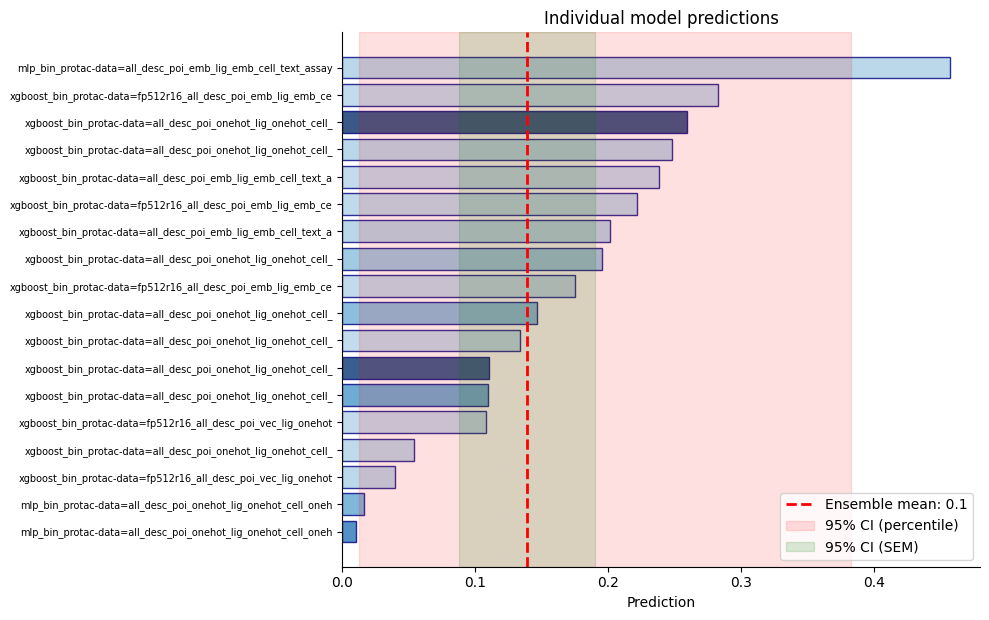

In [13]:
# Re-predict a sample and extract the first task's result
task_results_viz = predictor.predict(sample_dict)
result = next(iter(task_results_viz.values()))

# Collect per-model predictions
model_names = list(result.individual_predictions.keys())
preds = np.array([result.individual_predictions[n][0] for n in model_names])
weights = np.array([result.weights[n] for n in model_names])

# Sort by prediction value
order = np.argsort(preds)
model_names = [model_names[i] for i in order]
preds = preds[order]
weights = weights[order]

# Shorten long model names for display
short_names = [n.replace("model=", "")[:60] for n in model_names]

fig, ax = plt.subplots(figsize=(10, max(4, len(model_names) * 0.35)))
colors = plt.cm.Blues(weights / weights.max() * 0.7 + 0.3)
ax.barh(range(len(preds)), preds, color=colors, edgecolor="navy", alpha=0.8)
ax.axvline(result.weighted_mean[0], color="red", ls="--", lw=2,
           label=f"Ensemble mean: {result.weighted_mean[0]:.1f}")
ax.axvspan(result.ci_percentile_lower_95[0], result.ci_percentile_upper_95[0],
           alpha=0.12, color="red", label="95% CI (percentile)")
ax.axvspan(result.ci_sem_lower_95[0], result.ci_sem_upper_95[0],
           alpha=0.15, color="green", label="95% CI (SEM)")
ax.set_yticks(range(len(short_names)))
ax.set_yticklabels(short_names, fontsize=7)
ax.set_xlabel("Prediction")
ax.set_title("Individual model predictions")
ax.legend(loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Serialisation & Export

Prediction results can be serialised to a dictionary (for JSON export) or
inspected via the `.summary()` convenience method.

In [14]:
result_dict = result.to_dict()

# Pretty-print a subset
subset = {k: result_dict[k] for k in [
    "weighted_mean",
    "ci_percentile_lower_95", "ci_percentile_upper_95",
    "ci_sem_lower_95", "ci_sem_upper_95",
    "n_models", "task", "label_name",
]}
print(json.dumps(subset, indent=2))

{
  "weighted_mean": [
    0.1388114057963049
  ],
  "ci_percentile_lower_95": [
    0.01251491557341069
  ],
  "ci_percentile_upper_95": [
    0.38256176114082324
  ],
  "ci_sem_lower_95": [
    0.08742638349253129
  ],
  "ci_sem_upper_95": [
    0.19019642810007853
  ],
  "n_models": 18,
  "task": "bin",
  "label_name": "Binary Activity"
}


## 8. Fast Screening: Pre-encode Context Once, Screen Many SMILES

When evaluating many compounds against the **same** biological context
(same POI, E3 ligase, cell line, treatment time), encoding context features
once and reusing them is significantly faster than passing full `SampleInput`
objects for every molecule.

`transform_context` runs the heavy encoders (protein embeddings, cell-line
embeddings, categorical encoders, treatment-time scaler) once. The
subsequent `predict()` call only computes per-SMILES molecular features
(fingerprints / descriptors) and merges them with the cached context.

This pattern is ideal for **virtual screening**: fix a biological context
and sweep thousands of candidate SMILES.

> **Note:** this section uses `sample` and `smiles_list` defined in Section 2.

In [15]:
# Encode the biological context once from the SampleInput defined in section 2.
# SMILES is ignored — only POI, ligase, cell line, and treatment time matter.
context = predictor.transform_context(sample, verbose=True)

# Inspect one model's context feature shapes
first_model = next(iter(context.context_features))
print(f"\nContext feature keys for '{first_model}':")
for k, v in context.context_features[first_model].items():
    print(f"  {k}: {v.shape}")

  Preprocessed context for model 'model=mlp_bin_protac-data=all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=16'
  Preprocessed context for model 'model=mlp_bin_protac-data=all_desc_poi_onehot_lig_onehot_cell_onehot_assay_time_labels_Activity-group=scaffold-fold=13'
  Preprocessed context for model 'model=mlp_bin_protac-data=all_desc_poi_onehot_lig_onehot_cell_onehot_assay_time_labels_Activity-group=scaffold-fold=21'
  Preprocessed context for model 'model=xgboost_bin_protac-data=all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=2'
  Preprocessed context for model 'model=xgboost_bin_protac-data=all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=3'
  Preprocessed context for model 'model=xgboost_bin_protac-data=all_desc_poi_onehot_lig_onehot_cell_text_assay_time_labels_Activity-group=scaffold-fold=12'
  Preprocessed context for model 'm

In [16]:
# Screen the 30 SMILES from section 2 against the pre-encoded context.
# Only molecular features are computed per SMILES — context is reused.
screening_results, timings = predictor.predict(
    smiles_list,
    context=context,
    verbose=True,
    return_timings=True,
)

print(f"\nTimings: {timings}")
print(f"\nResults ({len(screening_results)} compounds):")
for i, task_dict in enumerate(screening_results):
    for task, pred in task_dict.items():
        print(f"  [{i:2d}] {task}: {pred.weighted_mean[0]:.3f} ± {pred.uncertainty_std[0]:.3f}")

Predicting: 100%|██████████| 18/18 [01:05<00:00,  3.65s/it]


Timings: {'smiles_featurize': 0.30655360221862793, 'inference': 3.7664811611175537, 'assemble': 0.02038717269897461}

Results (30 compounds):
  [ 0] bin: 0.663 ± 0.112
  [ 1] bin: 0.713 ± 0.154
  [ 2] bin: 0.501 ± 0.146
  [ 3] bin: 0.454 ± 0.128
  [ 4] bin: 0.594 ± 0.137
  [ 5] bin: 0.859 ± 0.119
  [ 6] bin: 0.304 ± 0.169
  [ 7] bin: 0.595 ± 0.131
  [ 8] bin: 0.537 ± 0.160
  [ 9] bin: 0.576 ± 0.139
  [10] bin: 0.563 ± 0.153
  [11] bin: 0.850 ± 0.119
  [12] bin: 0.722 ± 0.122
  [13] bin: 0.783 ± 0.135
  [14] bin: 0.265 ± 0.117
  [15] bin: 0.622 ± 0.134
  [16] bin: 0.492 ± 0.172
  [17] bin: 0.646 ± 0.126
  [18] bin: 0.655 ± 0.149
  [19] bin: 0.322 ± 0.198
  [20] bin: 0.864 ± 0.114
  [21] bin: 0.529 ± 0.126
  [22] bin: 0.701 ± 0.126
  [23] bin: 0.801 ± 0.145
  [24] bin: 0.602 ± 0.139
  [25] bin: 0.613 ± 0.106
  [26] bin: 0.902 ± 0.121
  [27] bin: 0.667 ± 0.113
  [28] bin: 0.869 ± 0.134
  [29] bin: 0.880 ± 0.134
